# F1 Podium Predictor

For this one, we need the MLFlow server running from now on. We need a virtual environment now for this so what we do is we run the following to create a virtual environment:
```
python3 -m venv .venv
```

Activate it:
```
source .venv/bin/activate
```

Install mlflow into it:
```
pip install mlflow
```

Then, from now on we can make sure that the MLFLow server is running whenever we do any training. The extra options here just set the local file locations:
```
mlflow server \
  --backend-store-uri sqlite:///mlruns.db \
  --default-artifact-root ./mlartifacts \
  --host 127.0.0.1 \
  --port 5000
  ```

## Importing the Libraries

In [2]:
import mlflow
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
from sklearn.metrics import roc_auc_score, brier_score_loss, RocCurveDisplay, roc_curve
from sklearn.calibration import calibration_curve

In [3]:
# Be aware, you'll need MLFlow running in the background here otherwise this will fail
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("f1-podium-predictor")

<Experiment: artifact_location='/home/dave/Work/F1Predictor/notebooks/mlartifacts/1', creation_time=1777477582938, experiment_id='1', last_update_time=1777477582938, lifecycle_stage='active', name='f1-podium-predictor', tags={}, trace_location=None, workspace='default'>

## Loading in the Data

In [4]:
race_df = pd.read_csv("../data/races.csv", na_values="\\N", parse_dates=["date", "quali_date"])
race_df.head()

,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN


In [5]:
res_df = pd.read_csv("../data/results.csv", na_values="\\N")
res_df.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22.0,1.0,1.0,1,1,10.0,58,1:34:50.616,5690616.0,39.0,2.0,1:27.452,218.300,1
1,2,18,2,2,3.0,5.0,2.0,2,2,8.0,58,+5.478,5696094.0,41.0,3.0,1:27.739,217.586,1
2,3,18,3,3,7.0,7.0,3.0,3,3,6.0,58,+8.163,5698779.0,41.0,5.0,1:28.090,216.719,1
3,4,18,4,4,5.0,11.0,4.0,4,4,5.0,58,+17.181,5707797.0,58.0,7.0,1:28.603,215.464,1
4,5,18,5,1,23.0,3.0,5.0,5,5,4.0,58,+18.014,5708630.0,43.0,1.0,1:27.418,218.385,1


In [6]:
constructor_df = pd.read_csv("../data/constructors.csv")
constructor_df.head()

,constructorId,constructorRef,name,nationality,url
0,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso


In [7]:
drivers_df = pd.read_csv("../data/drivers.csv", na_values="\\N", parse_dates=["dob"])
drivers_df.head()

,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44.0,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,NaN,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6.0,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14.0,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,NaN,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen


In [8]:
status_df = pd.read_csv("../data/status.csv", na_values="\\N")
status_df.head()

,statusId,status
0,1,Finished
1,2,Disqualified
2,3,Accident
3,4,Collision
4,5,Engine


## Setting up the Base Dataframe

In [9]:
full_base_race_data_df = pd.merge(
    left=res_df[["resultId", "raceId","driverId", "constructorId", "position", "statusId"]],
    right=race_df[["raceId","year","round","circuitId","name","date"]],
    on="raceId"
)

full_base_race_data_df = pd.merge(
    left=full_base_race_data_df,
    right=drivers_df[["driverId","dob","nationality"]],
    on="driverId"
)

full_base_race_data_df["podiumFinish"] = (full_base_race_data_df["position"] <= 3).astype(int)
full_base_race_data_df = full_base_race_data_df[full_base_race_data_df["year"] > 1990]

full_base_race_data_df

,resultId,raceId,driverId,constructorId,position,statusId,year,round,circuitId,name,date,dob,nationality,podiumFinish
0,1,18,1,1,1.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1985-01-07,British,1
1,2,18,2,2,2.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1977-05-10,German,1
2,3,18,3,3,3.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1985-06-27,German,1
3,4,18,4,4,4.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1981-07-29,Spanish,0
4,5,18,5,1,5.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1981-10-19,Finnish,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27299,27305,1171,4,117,18.0,11,2026,3,22,Japanese Grand Prix,2026-03-29,1981-07-29,Spanish,0
27300,27306,1171,822,216,19.0,11,2026,3,22,Japanese Grand Prix,2026-03-29,1989-08-28,Finnish,0
27301,27307,1171,848,3,20.0,12,2026,3,22,Japanese Grand Prix,2026-03-29,1996-03-23,Thai,0
27302,27308,1171,840,117,21.0,34,2026,3,22,Japanese Grand Prix,2026-03-29,1998-10-29,Canadian,0


In [10]:
training_base_race_data_df = full_base_race_data_df[full_base_race_data_df["year"] < 2025].copy()
training_base_race_data_df

,resultId,raceId,driverId,constructorId,position,statusId,year,round,circuitId,name,date,dob,nationality,podiumFinish
0,1,18,1,1,1.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1985-01-07,British,1
1,2,18,2,2,2.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1977-05-10,German,1
2,3,18,3,3,3.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1985-06-27,German,1
3,4,18,4,4,4.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1981-07-29,Spanish,0
4,5,18,5,1,5.0,1,2008,1,1,Australian Grand Prix,2008-03-16,1981-10-19,Finnish,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26754,26760,1144,825,210,16.0,11,2024,24,24,Abu Dhabi Grand Prix,2024-12-08,1992-10-05,Danish,0
26755,26761,1144,859,215,17.0,5,2024,24,24,Abu Dhabi Grand Prix,2024-12-08,2002-02-11,New Zealander,0
26756,26762,1144,822,15,NaN,130,2024,24,24,Abu Dhabi Grand Prix,2024-12-08,1989-08-28,Finnish,0
26757,26763,1144,861,3,NaN,5,2024,24,24,Abu Dhabi Grand Prix,2024-12-08,2003-05-27,Argentinian,0


In [11]:
base_features = ["driverId", "constructorId", "circuitId", "year", "round"]
base_cat_features = ["driverId", "constructorId", "circuitId"]

for col in base_cat_features:
    training_base_race_data_df[col] = training_base_race_data_df[col].astype("category")

X = training_base_race_data_df[base_features]
y = training_base_race_data_df["podiumFinish"]

In [12]:
train_mask = training_base_race_data_df["year"] <= 2023
val_mask   = (training_base_race_data_df["year"] > 2023) & (training_base_race_data_df["year"] < 2025)

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]

Retraining the model to get it into MLFlow

In [13]:
with mlflow.start_run(run_name="lgbm-baseline", description="Minimal feature set, no engineering"):
    model = lgb.LGBMClassifier(
        objective="binary",
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=20,
        verbose=-1
    )
    model.fit(X_train, y_train)
    
    preds = model.predict_proba(X_val)[:, 1]
    
    auc = roc_auc_score(y_val, preds)
    brier = brier_score_loss(y_val, preds)
    
    mlflow.set_tags({
        "model_type": "lightgbm",
        "feature_set": "baseline",
        "data_version": "1990-2024"
    })

    train_dataset = mlflow.data.from_pandas(
        training_base_race_data_df[train_mask], 
        name="f1-results-train", 
        targets="podiumFinish"
    )

    val_dataset = mlflow.data.from_pandas(
        training_base_race_data_df[val_mask], 
        name="f1-results-val", 
        targets="podiumFinish"
    )

    fig, ax = plt.subplots()
    
    fpr, tpr, _ = roc_curve(y_val, preds)
    
    ax.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.2f})")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title("ROC Curve - LightGBM Baseline")
    ax.legend(loc="lower right")
    
    mlflow.log_figure(fig, "roc_curve.png")
    plt.close(fig)

    mlflow.log_input(train_dataset, context="training")
    mlflow.log_input(val_dataset, context="validation")

    mlflow.log_params(model.get_params())
    mlflow.log_metric("val_roc_auc", auc)
    mlflow.log_metric("val_brier_score", brier)
    
    mlflow.lightgbm.log_model(model, name="lgbm-podium-predictor-baseline")

/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/04/30 08:50:26 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrar

🏃 View run lgbm-baseline at: http://127.0.0.1:5000/#/experiments/1/runs/26ce047ea4fa41c5b40b68dcddec42cc
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


## Implementing Walk Forward Validation

At the moment, we're using one validation set (the 2025 data) but we can actually do better than this. 

* Random-K folds: Doesn't work for our use case at all, if we randomly split the data into K sets then we're leaking future data into the current training.
* Expanding window/TimeSeriesSplit: This is better, but the training set doesn't have a stable size so we're adding more and more recent data into each split which means that the results can potentially behave differently but for different reasons other than the validation performance
* Rolling window splits: The best option for us, we define a window - say 10 races. We then slide this window over the years of data using the most recent one in that window as the validation. This is great because old seasons gradually age out, the windows are the same size the whole way through. Old data aging out might be a problem but it's quite likely that in our scenario, data from 1990 has little say in the race results of today so we're not too worried about that

In [14]:
# First up, before we do anything let's make a copy
training_base_fold_race_data_df = training_base_race_data_df.copy()

In [15]:
years = sorted(training_base_race_data_df["year"].unique())

train_window = 10   # The number of seasons in each training fold 
val_window = 1      # The number of season to run the validation on

folds = []

for i in range(len(years) - train_window - val_window + 1):
    train_years = years[i: i + train_window]
    val_years = years[i + train_window: i + train_window + val_window]
    folds.append((train_years, val_years))

pd.DataFrame(folds, columns=["TrainYears", "ValYears"])

,TrainYears,ValYears
0,"[1991, 1992, 1993, 1994, 1995, 1996, 1997, 199...",[2001]
1,"[1992, 1993, 1994, 1995, 1996, 1997, 1998, 199...",[2002]
2,"[1993, 1994, 1995, 1996, 1997, 1998, 1999, 200...",[2003]
3,"[1994, 1995, 1996, 1997, 1998, 1999, 2000, 200...",[2004]
4,"[1995, 1996, 1997, 1998, 1999, 2000, 2001, 200...",[2005]
5,"[1996, 1997, 1998, 1999, 2000, 2001, 2002, 200...",[2006]
6,"[1997, 1998, 1999, 2000, 2001, 2002, 2003, 200...",[2007]
7,"[1998, 1999, 2000, 2001, 2002, 2003, 2004, 200...",[2008]
8,"[1999, 2000, 2001, 2002, 2003, 2004, 2005, 200...",[2009]
9,"[2000, 2001, 2002, 2003, 2004, 2005, 2006, 200...",[2010]


In [16]:
for fold, (train_years, val_years) in enumerate(folds):
    train_mask = training_base_race_data_df["year"].isin(train_years)
    val_mask   = training_base_race_data_df["year"].isin(val_years)
    
    X_train_fold, y_train_fold = X[train_mask], y[train_mask]
    X_val_fold,   y_val_fold   = X[val_mask],   y[val_mask]

In [17]:
with mlflow.start_run(run_name="lgbm-baseline-walk-forward", description="Baseline LightGBM with rolling walk-forward cross-validation, no feature engineering") as parent_run:
    mlflow.set_tags({
        "model_type": "lightgbm",
        "feature_set": "baseline",
        "data_version": "1990-2024",
        "validation_strategy": "walk-forward"
    })
    
    fold_aucs, fold_briers = [], []
    all_preds, all_labels = [], []

    for fold, (train_years, val_years) in enumerate(folds):
        train_mask = training_base_race_data_df["year"].isin(train_years)
        val_mask   = training_base_race_data_df["year"].isin(val_years)
        
        X_train_fold, y_train_fold = X[train_mask], y[train_mask]
        X_val_fold,   y_val_fold   = X[val_mask],   y[val_mask]
        
        with mlflow.start_run(run_name=f"lgbm-baseline-fold-{fold}", nested=True):
            train_dataset = mlflow.data.from_pandas(
                training_base_race_data_df[train_mask],
                name=f"f1-results-train-fold-{fold}",
                targets="podiumFinish"
            )
            val_dataset = mlflow.data.from_pandas(
                training_base_race_data_df[val_mask],
                name=f"f1-results-val-fold-{fold}",
                targets="podiumFinish"
            )
            mlflow.log_input(train_dataset, context="training")
            mlflow.log_input(val_dataset, context="validation")
            
            model = lgb.LGBMClassifier(
                objective="binary",
                n_estimators=500,
                learning_rate=0.05,
                num_leaves=31,
                min_child_samples=20,
                verbose=-1
            )
            model.fit(X_train_fold, y_train_fold)
            preds = model.predict_proba(X_val_fold)[:, 1]

            all_preds.extend(preds)
            all_labels.extend(y_val_fold)
            
            fold_auc   = roc_auc_score(y_val_fold, preds)
            fold_brier = brier_score_loss(y_val_fold, preds)
            fold_aucs.append(fold_auc)
            fold_briers.append(fold_brier)
            
            mlflow.log_param("train_years", f"{train_years[0]}-{train_years[-1]}")
            mlflow.log_param("val_year", val_years[0])
            mlflow.log_metric("val_roc_auc", fold_auc)
            mlflow.log_metric("val_brier_score", fold_brier)
    
    mlflow.log_metric("mean_val_roc_auc", sum(fold_aucs) / len(fold_aucs))
    mlflow.log_metric("mean_val_brier_score", sum(fold_briers) / len(fold_briers))
    mlflow.log_params(model.get_params())
    
    with plt.style.context("dark_background"):
        fig, ax = plt.subplots()
        fpr, tpr, _ = roc_curve(y_val_fold, preds)
        ax.plot(fpr, tpr, label=f"ROC curve (AUC = {fold_auc:.2f})")
        ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
        ax.set_xlabel("False positive rate")
        ax.set_ylabel("True positive rate")
        ax.set_title("ROC Curve - LightGBM Baseline (final fold)")
        ax.legend(loc="lower right")
        mlflow.log_figure(fig, "roc_curve.png")
        plt.close(fig)
    
    mlflow.lightgbm.log_model(model, name="lgbm-podium-walking-predictor-baseline")

/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run lgbm-baseline-fold-0 at: http://127.0.0.1:5000/#/experiments/1/runs/ac5461eabc7848d2b4b0481c8cf563d0
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run lgbm-baseline-fold-1 at: http://127.0.0.1:5000/#/experiments/1/runs/3d49d7c1713641078f7994a0491d2951
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


...

🏃 View run lgbm-baseline-fold-22 at: http://127.0.0.1:5000/#/experiments/1/runs/f3cf673b193742f29c6edfc22da0f684
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run lgbm-baseline-fold-23 at: http://127.0.0.1:5000/#/experiments/1/runs/17338d79aecc458089383e2131ddbb57
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


2026/04/30 08:50:45 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run lgbm-baseline-walk-forward at: http://127.0.0.1:5000/#/experiments/1/runs/03317b63c96342e189dfd2cefa43d55c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


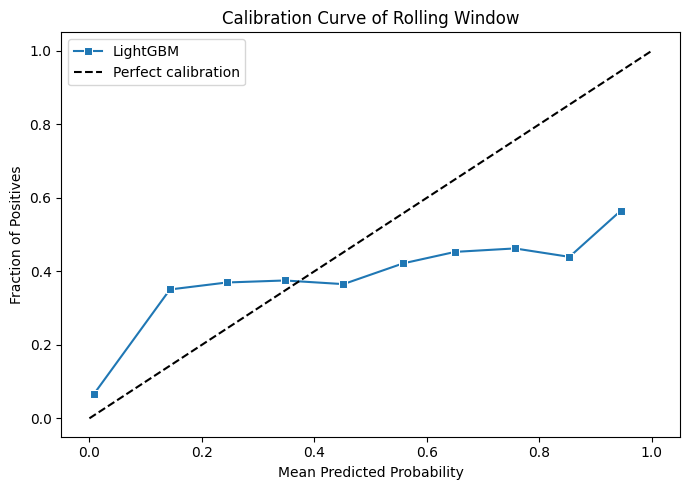

In [18]:
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

fraction_of_positives, mean_predicted_value = calibration_curve(
    all_labels, all_preds, n_bins=10
)

calib_df = pd.DataFrame({
    "Mean Predicted Probability": mean_predicted_value,
    "Fraction of Positives": fraction_of_positives
})

fig1, ax1 = plt.subplots(figsize=(7, 5))
sns.lineplot(
    data=calib_df,
    x="Mean Predicted Probability",
    y="Fraction of Positives",
    marker="s", label="LightGBM", ax=ax1
)
ax1.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax1.set_title("Calibration Curve of Rolling Window")
ax1.legend()
plt.tight_layout()
plt.show()

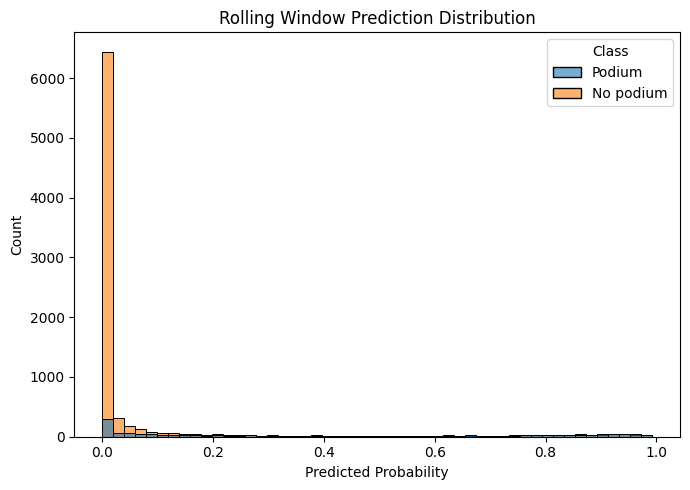

In [19]:
dist_df = pd.DataFrame({
    "Predicted Probability": all_preds,
    "Class": ["Podium" if y == 1 else "No podium" for y in all_labels]
})

fig2, ax2 = plt.subplots(figsize=(7, 5))
sns.histplot(
    data=dist_df,
    x="Predicted Probability",
    hue="Class",
    bins=50,
    alpha=0.6,
    ax=ax2
)
ax2.set_title("Rolling Window Prediction Distribution")
plt.tight_layout()
plt.show()

## Addressing the Imbalance

In [20]:
with mlflow.start_run(run_name="lgbm-baseline-walk-forward-scaled", description="Baseline LightGBM with rolling walk-forward cross-validation, no feature engineering") as parent_run:
    mlflow.set_tags({
        "model_type": "lightgbm",
        "feature_set": "baseline",
        "data_version": "1990-2024",
        "validation_strategy": "walk-forward"
    })
    
    fold_aucs, fold_briers = [], []
    all_preds, all_labels = [], []
    
    for fold, (train_years, val_years) in enumerate(folds):
        train_mask = training_base_race_data_df["year"].isin(train_years)
        val_mask   = training_base_race_data_df["year"].isin(val_years)
        
        X_train_fold, y_train_fold = X[train_mask], y[train_mask]
        X_val_fold,   y_val_fold   = X[val_mask],   y[val_mask]
        
        with mlflow.start_run(run_name=f"lgbm-baseline-fold-{fold}", nested=True):
            train_dataset = mlflow.data.from_pandas(
                training_base_race_data_df[train_mask],
                name=f"f1-results-train-fold-{fold}",
                targets="podiumFinish"
            )
            val_dataset = mlflow.data.from_pandas(
                training_base_race_data_df[val_mask],
                name=f"f1-results-val-fold-{fold}",
                targets="podiumFinish"
            )
            mlflow.log_input(train_dataset, context="training")
            mlflow.log_input(val_dataset, context="validation")
            
            model = lgb.LGBMClassifier(
                objective="binary",
                n_estimators=500,
                learning_rate=0.05,
                num_leaves=31,
                min_child_samples=20,
                scale_pos_weight=5.67,
                verbose=-1,
            )
            model.fit(X_train_fold, y_train_fold)
            preds = model.predict_proba(X_val_fold)[:, 1]

            all_preds.extend(preds)
            all_labels.extend(y_val_fold)
            
            fold_auc   = roc_auc_score(y_val_fold, preds)
            fold_brier = brier_score_loss(y_val_fold, preds)
            fold_aucs.append(fold_auc)
            fold_briers.append(fold_brier)
            
            mlflow.log_param("train_years", f"{train_years[0]}-{train_years[-1]}")
            mlflow.log_param("val_year", val_years[0])
            mlflow.log_metric("val_roc_auc", fold_auc)
            mlflow.log_metric("val_brier_score", fold_brier)
    
    mlflow.log_metric("mean_val_roc_auc", sum(fold_aucs) / len(fold_aucs))
    mlflow.log_metric("mean_val_brier_score", sum(fold_briers) / len(fold_briers))
    mlflow.log_params(model.get_params())
    
    with plt.style.context("dark_background"):
        fig, ax = plt.subplots()
        fpr, tpr, _ = roc_curve(y_val_fold, preds)
        ax.plot(fpr, tpr, label=f"ROC curve (AUC = {fold_auc:.2f})")
        ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
        ax.set_xlabel("False positive rate")
        ax.set_ylabel("True positive rate")
        ax.set_title("ROC Curve - LightGBM Baseline (final fold)")
        ax.legend(loc="lower right")
        mlflow.log_figure(fig, "roc_curve.png")
        plt.close(fig)
    
    mlflow.lightgbm.log_model(model, name="lgbm-podium-walking-predictor-scaled-baseline")

/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run lgbm-baseline-fold-0 at: http://127.0.0.1:5000/#/experiments/1/runs/c3b85b85b7384b0c84865f1759352721
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run lgbm-baseline-fold-1 at: http://127.0.0.1:5000/#/experiments/1/runs/66da731167a64359862e13c8af20f130
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


...

🏃 View run lgbm-baseline-fold-22 at: http://127.0.0.1:5000/#/experiments/1/runs/86901d89831046d48a17d0c9b77d5318
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run lgbm-baseline-fold-23 at: http://127.0.0.1:5000/#/experiments/1/runs/9cb5b035b05a467aa86299b8e45c5538
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


2026/04/30 08:51:03 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run lgbm-baseline-walk-forward-scaled at: http://127.0.0.1:5000/#/experiments/1/runs/0095899d135c4224a41cb53d3479f6d0
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


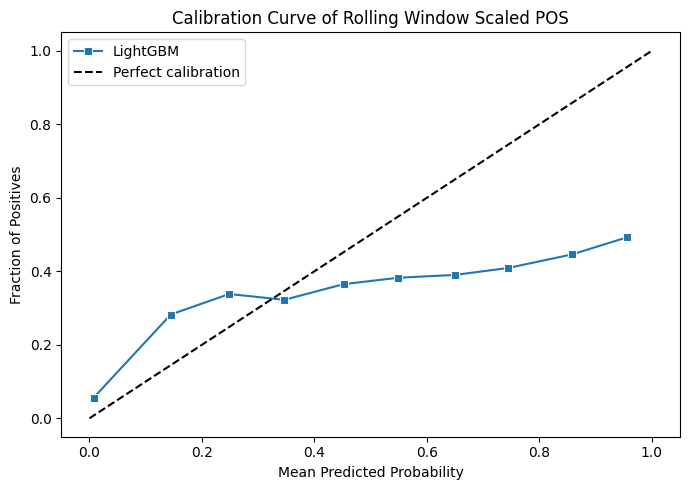

In [21]:
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

fraction_of_positives, mean_predicted_value = calibration_curve(
    all_labels, all_preds, n_bins=10
)

calib_df = pd.DataFrame({
    "Mean Predicted Probability": mean_predicted_value,
    "Fraction of Positives": fraction_of_positives
})

fig1, ax1 = plt.subplots(figsize=(7, 5))
sns.lineplot(
    data=calib_df,
    x="Mean Predicted Probability",
    y="Fraction of Positives",
    marker="s", label="LightGBM", ax=ax1
)
ax1.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax1.set_title("Calibration Curve of Rolling Window Scaled POS")
ax1.legend()
plt.tight_layout()
plt.show()

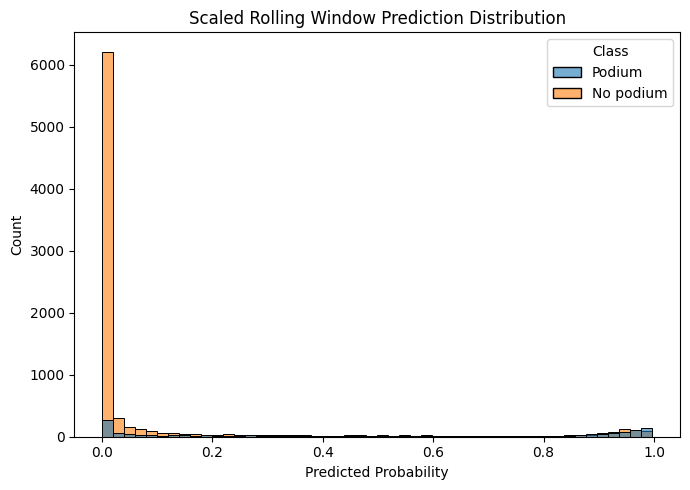

In [22]:
dist_df = pd.DataFrame({
    "Predicted Probability": all_preds,
    "Class": ["Podium" if y == 1 else "No podium" for y in all_labels]
})

fig2, ax2 = plt.subplots(figsize=(7, 5))
sns.histplot(
    data=dist_df,
    x="Predicted Probability",
    hue="Class",
    bins=50,
    alpha=0.6,
    ax=ax2
)
ax2.set_title("Scaled Rolling Window Prediction Distribution")
plt.tight_layout()
plt.show()

## Feature time

### Rolling Driver Performance

In [23]:
training_base_driver_en_1_data_df = (
    training_base_race_data_df
    .sort_values(["driverId", "year", "round"])
    .copy()
)

training_base_driver_en_1_data_df["driver_podium_rate_3"] = (
    training_base_driver_en_1_data_df.groupby("driverId", observed=True)["podiumFinish"]
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

training_base_driver_en_1_data_df["driver_podium_rate_3"] = training_base_driver_en_1_data_df["driver_podium_rate_3"].fillna(0)
training_base_driver_en_1_data_df.head()

,resultId,raceId,driverId,constructorId,position,statusId,year,round,circuitId,name,date,dob,nationality,podiumFinish,driver_podium_rate_3
370,371,36,1,1,3.0,1,2007,1,1,Australian Grand Prix,2007-03-18,1985-01-07,British,1,0.0
391,392,37,1,1,2.0,1,2007,2,2,Malaysian Grand Prix,2007-04-08,1985-01-07,British,1,1.0
413,414,38,1,1,2.0,1,2007,3,3,Bahrain Grand Prix,2007-04-15,1985-01-07,British,1,1.0
435,436,39,1,1,2.0,1,2007,4,4,Spanish Grand Prix,2007-05-13,1985-01-07,British,1,1.0
457,458,40,1,1,2.0,1,2007,5,6,Monaco Grand Prix,2007-05-27,1985-01-07,British,1,1.0


In [24]:
training_base_driver_en_1_data_df["driver_podium_rate_5"] = (
    training_base_driver_en_1_data_df.groupby("driverId", observed=True)["podiumFinish"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

training_base_driver_en_1_data_df["driver_podium_rate_5"] = training_base_driver_en_1_data_df["driver_podium_rate_5"].fillna(0)
training_base_driver_en_1_data_df.head()

,resultId,raceId,driverId,constructorId,position,statusId,year,round,circuitId,name,date,dob,nationality,podiumFinish,driver_podium_rate_3,driver_podium_rate_5
370,371,36,1,1,3.0,1,2007,1,1,Australian Grand Prix,2007-03-18,1985-01-07,British,1,0.0,0.0
391,392,37,1,1,2.0,1,2007,2,2,Malaysian Grand Prix,2007-04-08,1985-01-07,British,1,1.0,1.0
413,414,38,1,1,2.0,1,2007,3,3,Bahrain Grand Prix,2007-04-15,1985-01-07,British,1,1.0,1.0
435,436,39,1,1,2.0,1,2007,4,4,Spanish Grand Prix,2007-05-13,1985-01-07,British,1,1.0,1.0
457,458,40,1,1,2.0,1,2007,5,6,Monaco Grand Prix,2007-05-27,1985-01-07,British,1,1.0,1.0


In [25]:
training_base_driver_en_1_data_df["driver_podium_rate_10"] = (
    training_base_driver_en_1_data_df.groupby("driverId", observed=True)["podiumFinish"]
    .transform(lambda x: x.shift(1).rolling(10, min_periods=1).mean())
)

training_base_driver_en_1_data_df["driver_podium_rate_10"] = training_base_driver_en_1_data_df["driver_podium_rate_10"].fillna(0)
training_base_driver_en_1_data_df.head()

,resultId,raceId,driverId,constructorId,position,statusId,year,round,circuitId,name,date,dob,nationality,podiumFinish,driver_podium_rate_3,driver_podium_rate_5,driver_podium_rate_10
370,371,36,1,1,3.0,1,2007,1,1,Australian Grand Prix,2007-03-18,1985-01-07,British,1,0.0,0.0,0.0
391,392,37,1,1,2.0,1,2007,2,2,Malaysian Grand Prix,2007-04-08,1985-01-07,British,1,1.0,1.0,1.0
413,414,38,1,1,2.0,1,2007,3,3,Bahrain Grand Prix,2007-04-15,1985-01-07,British,1,1.0,1.0,1.0
435,436,39,1,1,2.0,1,2007,4,4,Spanish Grand Prix,2007-05-13,1985-01-07,British,1,1.0,1.0,1.0
457,458,40,1,1,2.0,1,2007,5,6,Monaco Grand Prix,2007-05-27,1985-01-07,British,1,1.0,1.0,1.0


In [26]:
years = sorted(training_base_driver_en_1_data_df["year"].unique())

train_window = 10   # The number of seasons in each training fold 
val_window = 1      # The number of season to run the validation on

folds = []

for i in range(len(years) - train_window - val_window + 1):
    train_years = years[i: i + train_window]
    val_years = years[i + train_window: i + train_window + val_window]
    folds.append((train_years, val_years))

pd.DataFrame(folds, columns=["TrainYears", "ValYears"])

,TrainYears,ValYears
0,"[1991, 1992, 1993, 1994, 1995, 1996, 1997, 199...",[2001]
1,"[1992, 1993, 1994, 1995, 1996, 1997, 1998, 199...",[2002]
2,"[1993, 1994, 1995, 1996, 1997, 1998, 1999, 200...",[2003]
3,"[1994, 1995, 1996, 1997, 1998, 1999, 2000, 200...",[2004]
4,"[1995, 1996, 1997, 1998, 1999, 2000, 2001, 200...",[2005]
5,"[1996, 1997, 1998, 1999, 2000, 2001, 2002, 200...",[2006]
6,"[1997, 1998, 1999, 2000, 2001, 2002, 2003, 200...",[2007]
7,"[1998, 1999, 2000, 2001, 2002, 2003, 2004, 200...",[2008]
8,"[1999, 2000, 2001, 2002, 2003, 2004, 2005, 200...",[2009]
9,"[2000, 2001, 2002, 2003, 2004, 2005, 2006, 200...",[2010]


In [27]:
engineered_features = [
    "driverId", "constructorId", "circuitId", "year", "round",
    "driver_podium_rate_3", "driver_podium_rate_5", "driver_podium_rate_10"
]
engineered_cat_features = ["driverId", "constructorId", "circuitId"]

for col in engineered_cat_features:
    training_base_driver_en_1_data_df[col] = training_base_driver_en_1_data_df[col].astype("category")

X = training_base_driver_en_1_data_df[engineered_features]
y = training_base_driver_en_1_data_df["podiumFinish"]

In [28]:
with mlflow.start_run(run_name="lgbm-driver-performance-walk-forward-scaled", description="LightGBM with rolling walk-forward cross-validation, and rolling driver performance") as parent_run:
    mlflow.set_tags({
        "model_type": "lightgbm",
        "feature_set": "driverPerformance",
        "data_version": "1990-2024",
        "validation_strategy": "walk-forward"
    })
    
    fold_aucs, fold_briers = [], []
    all_preds, all_labels = [], []
    
    for fold, (train_years, val_years) in enumerate(folds):
        train_mask = training_base_driver_en_1_data_df["year"].isin(train_years)
        val_mask   = training_base_driver_en_1_data_df["year"].isin(val_years)
        
        X_train_fold, y_train_fold = X[train_mask], y[train_mask]
        X_val_fold,   y_val_fold   = X[val_mask],   y[val_mask]
        
        with mlflow.start_run(run_name=f"lgbm-baseline-fold-{fold}", nested=True):
            train_dataset = mlflow.data.from_pandas(
                training_base_driver_en_1_data_df[train_mask],
                name=f"f1-results-train-fold-{fold}",
                targets="podiumFinish"
            )
            val_dataset = mlflow.data.from_pandas(
                training_base_driver_en_1_data_df[val_mask],
                name=f"f1-results-val-fold-{fold}",
                targets="podiumFinish"
            )
            mlflow.log_input(train_dataset, context="training")
            mlflow.log_input(val_dataset, context="validation")
            
            model = lgb.LGBMClassifier(
                objective="binary",
                n_estimators=500,
                learning_rate=0.05,
                num_leaves=31,
                min_child_samples=20,
                scale_pos_weight=5.67,
                verbose=-1,
            )
            model.fit(X_train_fold, y_train_fold)
            preds = model.predict_proba(X_val_fold)[:, 1]

            all_preds.extend(preds)
            all_labels.extend(y_val_fold)
            
            fold_auc   = roc_auc_score(y_val_fold, preds)
            fold_brier = brier_score_loss(y_val_fold, preds)
            fold_aucs.append(fold_auc)
            fold_briers.append(fold_brier)
            
            mlflow.log_param("train_years", f"{train_years[0]}-{train_years[-1]}")
            mlflow.log_param("val_year", val_years[0])
            mlflow.log_metric("val_roc_auc", fold_auc)
            mlflow.log_metric("val_brier_score", fold_brier)
    
    mlflow.log_metric("mean_val_roc_auc", sum(fold_aucs) / len(fold_aucs))
    mlflow.log_metric("mean_val_brier_score", sum(fold_briers) / len(fold_briers))
    mlflow.log_params(model.get_params())
    
    with plt.style.context("dark_background"):
        fig, ax = plt.subplots()
        fpr, tpr, _ = roc_curve(y_val_fold, preds)
        ax.plot(fpr, tpr, label=f"ROC curve (AUC = {fold_auc:.2f})")
        ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
        ax.set_xlabel("False positive rate")
        ax.set_ylabel("True positive rate")
        ax.set_title("ROC Curve - LightGBM Baseline (final fold)")
        ax.legend(loc="lower right")
        mlflow.log_figure(fig, "roc_curve.png")
        plt.close(fig)
    
    mlflow.lightgbm.log_model(model, name="lgbm-podium-walking-predictor-scaled-driver-performance")

/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run lgbm-baseline-fold-0 at: http://127.0.0.1:5000/#/experiments/1/runs/b9ca194aa3d543f29c2650129070f7e8
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run lgbm-baseline-fold-1 at: http://127.0.0.1:5000/#/experiments/1/runs/d3f31013106844f0a1fa41719571f72b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


...

🏃 View run lgbm-baseline-fold-22 at: http://127.0.0.1:5000/#/experiments/1/runs/cdb6d3efd21f4ff6a1f8b00cc5cfd020
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run lgbm-baseline-fold-23 at: http://127.0.0.1:5000/#/experiments/1/runs/c6e3194420cf4fc795c24176ff45c6ab
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


2026/04/30 08:51:22 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run lgbm-driver-performance-walk-forward-scaled at: http://127.0.0.1:5000/#/experiments/1/runs/d732891053cc44538b5d9a7991c7722f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

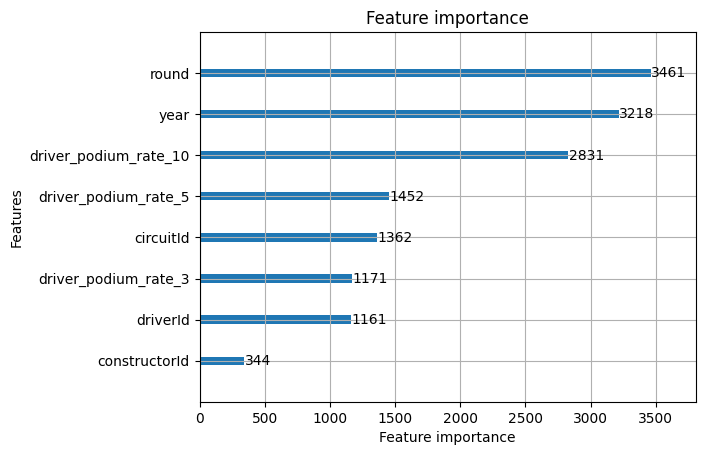

In [34]:
lgb.plot_importance(model,importance_type='split')

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

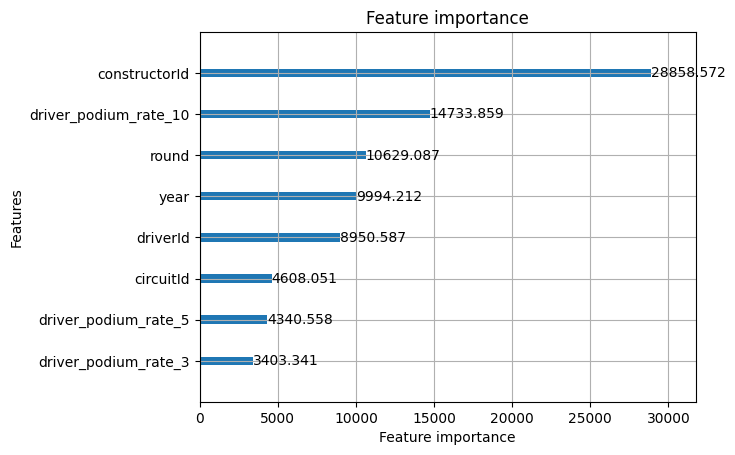

In [30]:
lgb.plot_importance(model,importance_type='gain')

Okay interesting! So, we need to talk about Split vs Gain here:
* Split is how many times a feature was used as a split point across all trees, it's biaseed towards features that get used a lot even if they're not very important though e.g. if it's being used as a low level tie-breaker a lot
* Gain is a measure of how much the average improvement in the loss function was that a feature produced, it instead is biased towards high cardinality features e.g. constructor ID where yhou can do high-information splits early in the trees.

For example, constructor doesn't get used a lot (Low splits) but when it is used it's contributing a lot (high gain). So there is significant signal there

Round/year is different, theye're used a *lot* for splits but the value is mild so it's probaly using them more as a tie-breaker than for real value

Driver podium rate for the last 10 races though is *high for both* so it's used a lot AND it's genuinely performing well!

---

We can also see that year has dropped off significantly, our new features for rolling performance seems to be encoding very well "how well a driver is performing well right now" that was all being proxied by year. So, this is good news! We're untangling the mess of year

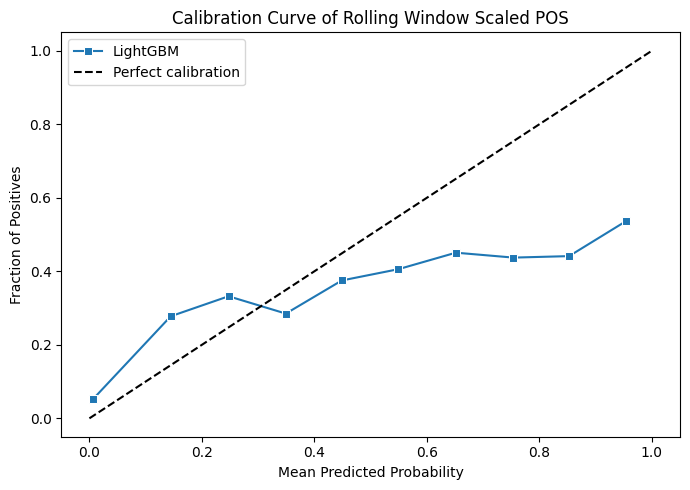

In [31]:
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

fraction_of_positives, mean_predicted_value = calibration_curve(
    all_labels, all_preds, n_bins=10
)

calib_df = pd.DataFrame({
    "Mean Predicted Probability": mean_predicted_value,
    "Fraction of Positives": fraction_of_positives
})

fig1, ax1 = plt.subplots(figsize=(7, 5))
sns.lineplot(
    data=calib_df,
    x="Mean Predicted Probability",
    y="Fraction of Positives",
    marker="s", label="LightGBM", ax=ax1
)
ax1.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax1.set_title("Calibration Curve of Rolling Window Scaled POS")
ax1.legend()
plt.tight_layout()
plt.show()

In [32]:
fpr, tpr, thresholds = roc_curve(all_labels, all_preds)
auc  = roc_auc_score(all_labels, all_preds)
brier = brier_score_loss(all_labels, all_preds)

print(f"AUC:   {auc:.4f}  (baseline: 0.79)")
print(f"Brier: {brier:.4f}  (baseline: 0.12)")

AUC:   0.8440  (baseline: 0.79)
Brier: 0.1174  (baseline: 0.12)


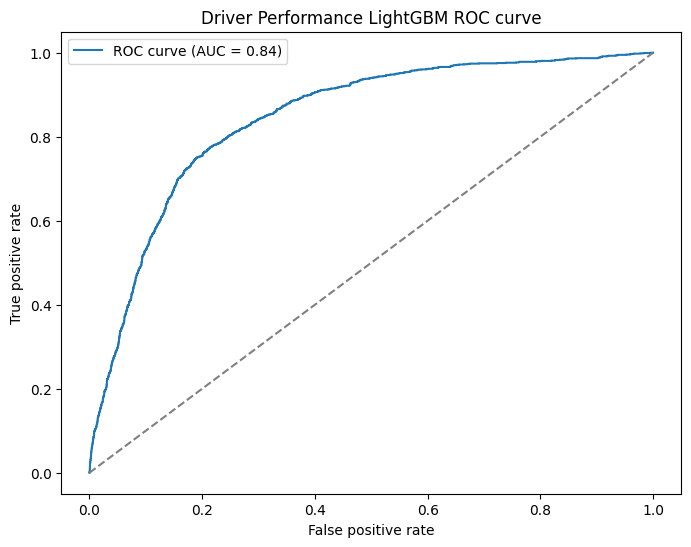

In [33]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Driver Performance LightGBM ROC curve')
plt.legend()
plt.show()

### Constructor Podium Rate

What do we build upon? We're going to build on top of the driver features that we just built. Why? Even though we might isolate the changes so that in theory we would only see how the constructor features perform this doesn't account for the interplay between features e.g. "Do the constructor features look better, because they're compensating for the driver features missing?"

We want to know *Do they add value above and beyond what the driver features give?*

In [39]:
training_base_driver_en_2_data_df = (
    training_base_driver_en_1_data_df
    .sort_values(["driverId", "year", "round"])
    .copy()
)

In [40]:

training_base_driver_en_2_data_df["constructor_podium_rate_3"] = (
    training_base_driver_en_2_data_df.groupby("constructorId", observed=True)["podiumFinish"]
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

training_base_driver_en_2_data_df["constructor_podium_rate_3"] = training_base_driver_en_2_data_df["constructor_podium_rate_3"].fillna(0)
training_base_driver_en_2_data_df.head()

,resultId,raceId,driverId,constructorId,position,statusId,year,round,circuitId,name,date,dob,nationality,podiumFinish,driver_podium_rate_3,driver_podium_rate_5,driver_podium_rate_10,constructor_podium_rate_3
370,371,36,1,1,3.0,1,2007,1,1,Australian Grand Prix,2007-03-18,1985-01-07,British,1,0.0,0.0,0.0,0.0
391,392,37,1,1,2.0,1,2007,2,2,Malaysian Grand Prix,2007-04-08,1985-01-07,British,1,1.0,1.0,1.0,1.0
413,414,38,1,1,2.0,1,2007,3,3,Bahrain Grand Prix,2007-04-15,1985-01-07,British,1,1.0,1.0,1.0,1.0
435,436,39,1,1,2.0,1,2007,4,4,Spanish Grand Prix,2007-05-13,1985-01-07,British,1,1.0,1.0,1.0,1.0
457,458,40,1,1,2.0,1,2007,5,6,Monaco Grand Prix,2007-05-27,1985-01-07,British,1,1.0,1.0,1.0,1.0


In [41]:

training_base_driver_en_2_data_df["constructor_podium_rate_5"] = (
    training_base_driver_en_2_data_df.groupby("constructorId", observed=True)["podiumFinish"]
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

training_base_driver_en_2_data_df["constructor_podium_rate_5"] = training_base_driver_en_2_data_df["constructor_podium_rate_5"].fillna(0)
training_base_driver_en_2_data_df.head()

,resultId,raceId,driverId,constructorId,position,statusId,year,round,circuitId,name,date,dob,nationality,podiumFinish,driver_podium_rate_3,driver_podium_rate_5,driver_podium_rate_10,constructor_podium_rate_3,constructor_podium_rate_5
370,371,36,1,1,3.0,1,2007,1,1,Australian Grand Prix,2007-03-18,1985-01-07,British,1,0.0,0.0,0.0,0.0,0.0
391,392,37,1,1,2.0,1,2007,2,2,Malaysian Grand Prix,2007-04-08,1985-01-07,British,1,1.0,1.0,1.0,1.0,1.0
413,414,38,1,1,2.0,1,2007,3,3,Bahrain Grand Prix,2007-04-15,1985-01-07,British,1,1.0,1.0,1.0,1.0,1.0
435,436,39,1,1,2.0,1,2007,4,4,Spanish Grand Prix,2007-05-13,1985-01-07,British,1,1.0,1.0,1.0,1.0,1.0
457,458,40,1,1,2.0,1,2007,5,6,Monaco Grand Prix,2007-05-27,1985-01-07,British,1,1.0,1.0,1.0,1.0,1.0


In [42]:

training_base_driver_en_2_data_df["constructor_podium_rate_10"] = (
    training_base_driver_en_2_data_df.groupby("constructorId", observed=True)["podiumFinish"]
    .transform(lambda x: x.shift(1).rolling(10, min_periods=1).mean())
)

training_base_driver_en_2_data_df["constructor_podium_rate_10"] = training_base_driver_en_2_data_df["constructor_podium_rate_10"].fillna(0)
training_base_driver_en_2_data_df.head()

,resultId,raceId,driverId,constructorId,position,statusId,year,round,circuitId,name,date,dob,nationality,podiumFinish,driver_podium_rate_3,driver_podium_rate_5,driver_podium_rate_10,constructor_podium_rate_3,constructor_podium_rate_5,constructor_podium_rate_10
370,371,36,1,1,3.0,1,2007,1,1,Australian Grand Prix,2007-03-18,1985-01-07,British,1,0.0,0.0,0.0,0.0,0.0,0.0
391,392,37,1,1,2.0,1,2007,2,2,Malaysian Grand Prix,2007-04-08,1985-01-07,British,1,1.0,1.0,1.0,1.0,1.0,1.0
413,414,38,1,1,2.0,1,2007,3,3,Bahrain Grand Prix,2007-04-15,1985-01-07,British,1,1.0,1.0,1.0,1.0,1.0,1.0
435,436,39,1,1,2.0,1,2007,4,4,Spanish Grand Prix,2007-05-13,1985-01-07,British,1,1.0,1.0,1.0,1.0,1.0,1.0
457,458,40,1,1,2.0,1,2007,5,6,Monaco Grand Prix,2007-05-27,1985-01-07,British,1,1.0,1.0,1.0,1.0,1.0,1.0


### Evaluating Constructor Features

In [51]:
def GenerateFolds(dataframe, train_window, val_window):
	years = sorted(dataframe["year"].unique())

	folds = []

	for i in range(len(years) - train_window - val_window + 1):
		train_years = years[i: i + train_window]
		val_years = years[i + train_window: i + train_window + val_window]
		folds.append((train_years, val_years))
	    
	return folds

folds = GenerateFolds(training_base_driver_en_2_data_df, train_window=10, val_window=1)

In [52]:
def GenXy(dataFrame, engineered_features, engineered_cat_features):
    for col in engineered_cat_features:
        dataFrame[col] = dataFrame[col].astype("category")
    
    X = dataFrame[engineered_features]
    y = dataFrame["podiumFinish"]
    
    return (X,y)

engineered_features = [
    "driverId", "constructorId", "circuitId", "year", "round",
    "driver_podium_rate_3", "driver_podium_rate_5", "driver_podium_rate_10",
    "constructor_podium_rate_3", "constructor_podium_rate_5", "constructor_podium_rate_10"
]

engineered_cat_features = ["driverId", "constructorId", "circuitId"]

X, y = GenXy(training_base_driver_en_2_data_df, engineered_features, engineered_cat_features)

In [53]:
def TrainModel(X, y, dataFrame, folds, config):
    with mlflow.start_run(run_name=config["run_name"], description=config["description"]) as parent_run:
        mlflow.set_tags(config["tags"])
        
        fold_aucs, fold_briers = [], []
        all_preds, all_labels = [], []
        
        for fold, (train_years, val_years) in enumerate(folds):
            train_mask = dataFrame["year"].isin(train_years)
            val_mask   = dataFrame["year"].isin(val_years)
            
            X_train_fold, y_train_fold = X[train_mask], y[train_mask]
            X_val_fold,   y_val_fold   = X[val_mask],   y[val_mask]
            
            with mlflow.start_run(run_name=f"lgbm-baseline-fold-{fold}", nested=True):
                train_dataset = mlflow.data.from_pandas(
                    dataFrame[train_mask],
                    name=f"{config['run_name']}-train-fold-{fold}",
                    targets="podiumFinish"
                )
                val_dataset = mlflow.data.from_pandas(
                    dataFrame[val_mask],
                    name=f"{config['run_name']}-val-fold-{fold}",
                    targets="podiumFinish"
                )
                mlflow.log_input(train_dataset, context="training")
                mlflow.log_input(val_dataset, context="validation")
                
                model = lgb.LGBMClassifier(**config["model_params"])

                model.fit(X_train_fold, y_train_fold)
                preds = model.predict_proba(X_val_fold)[:, 1]

                all_preds.extend(preds)
                all_labels.extend(y_val_fold)
                
                fold_auc   = roc_auc_score(y_val_fold, preds)
                fold_brier = brier_score_loss(y_val_fold, preds)
                fold_aucs.append(fold_auc)
                fold_briers.append(fold_brier)
                
                mlflow.log_param("train_years", f"{train_years[0]}-{train_years[-1]}")
                mlflow.log_param("val_year", val_years[0])
                mlflow.log_metric("val_roc_auc", fold_auc)
                mlflow.log_metric("val_brier_score", fold_brier)
        
        mlflow.log_metric("mean_val_roc_auc", sum(fold_aucs) / len(fold_aucs))
        mlflow.log_metric("mean_val_brier_score", sum(fold_briers) / len(fold_briers))
        mlflow.log_params(model.get_params())
        
        with plt.style.context("dark_background"):
            fig, ax = plt.subplots()
            fpr, tpr, _ = roc_curve(y_val_fold, preds)
            ax.plot(fpr, tpr, label=f"ROC curve (AUC = {fold_auc:.2f})")
            ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
            ax.set_xlabel("False positive rate")
            ax.set_ylabel("True positive rate")
            ax.set_title("ROC Curve - LightGBM Baseline (final fold)")
            ax.legend(loc="lower right")
            mlflow.log_figure(fig, "roc_curve.png")
            plt.close(fig)
        
        mlflow.lightgbm.log_model(model, name=config["run_name"])

TrainModel(X, y, training_base_driver_en_2_data_df, folds, {
    "run_name": "lgbm-driver-2-performance-walk-forward-scaled",
    "description": "LightGBM with rolling walk-forward cross-validation, with driver and rolling constructor stats",
    "tags": {
        "model_type": "lightgbm",
        "feature_set": "driverPerformance + constructorPerformance",
        "data_version": "1990-2024",
        "validation_strategy": "walk-forward"
    },
    "model_params": {
        "objective": "binary",
        "n_estimators": 500,
        "learning_rate": 0.05,
        "num_leaves": 31,
        "min_child_samples": 20,
        "scale_pos_weight": 5.67,
        "verbose": -1,
    }
})

/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run lgbm-baseline-fold-0 at: http://127.0.0.1:5000/#/experiments/1/runs/57e914dc18214b7a8a36e09c9a27f27c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run lgbm-baseline-fold-1 at: http://127.0.0.1:5000/#/experiments/1/runs/0933bf1ab3bd454da15a6fcbb6af5206
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


...

🏃 View run lgbm-baseline-fold-22 at: http://127.0.0.1:5000/#/experiments/1/runs/0a0ece9d046248488f536ddf50d618bf
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


/home/dave/miniconda3/envs/nlp-gpu/lib/python3.10/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run lgbm-baseline-fold-23 at: http://127.0.0.1:5000/#/experiments/1/runs/8d7e7aec2ad94962a93ba47b6a30cadc
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


2026/04/30 10:05:04 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run lgbm-driver-2-performance-walk-forward-scaled at: http://127.0.0.1:5000/#/experiments/1/runs/31c301d0b08549b580fd6391203f3d51
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


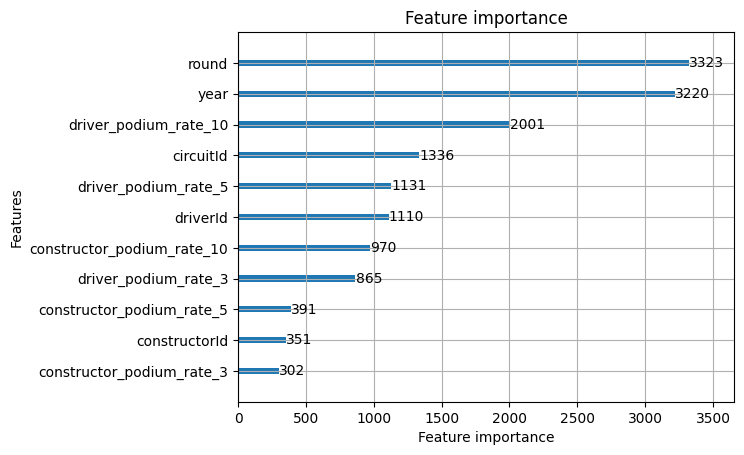

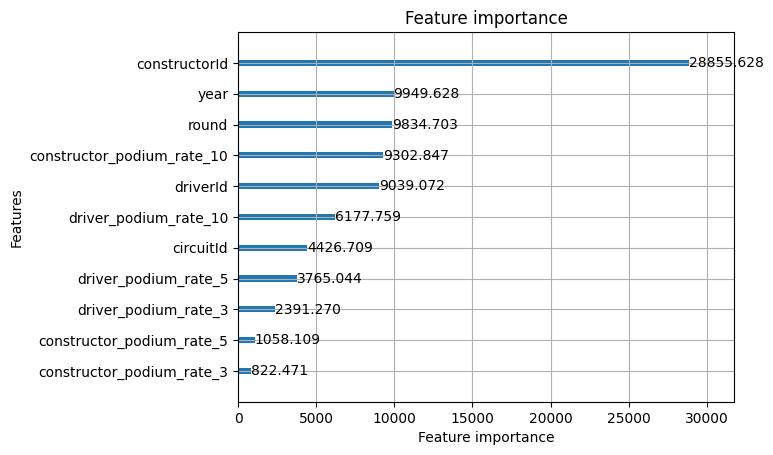

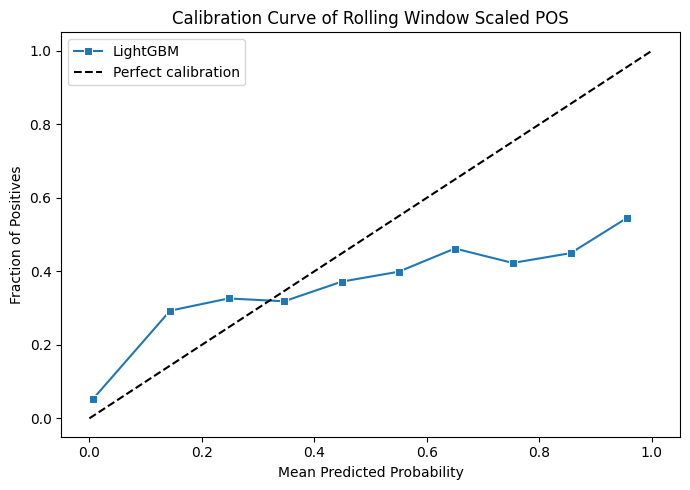

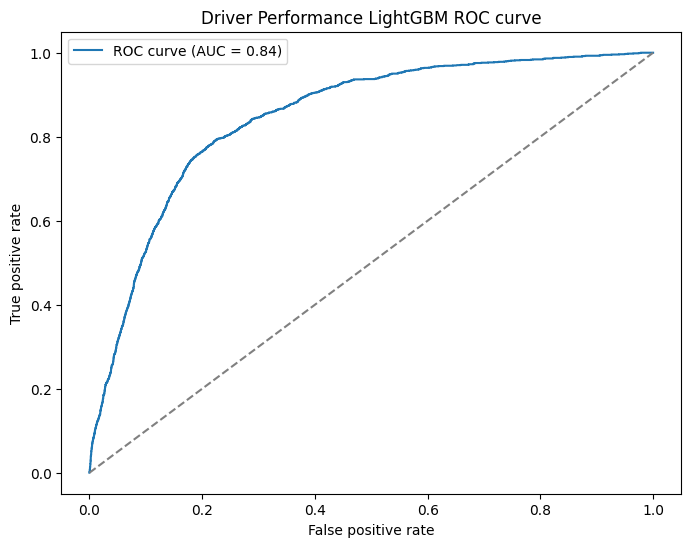

AUC:   0.8463  (baseline: 0.79)
Brier: 0.1167  (baseline: 0.12)


In [49]:
def generateCalibrationGraph(cg_title, all_preds, all_labels):
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    fraction_of_positives, mean_predicted_value = calibration_curve(
        all_labels, all_preds, n_bins=10
    )

    calib_df = pd.DataFrame({
        "Mean Predicted Probability": mean_predicted_value,
        "Fraction of Positives": fraction_of_positives
    })

    _, ax1 = plt.subplots(figsize=(7, 5))
    sns.lineplot(
        data=calib_df,
        x="Mean Predicted Probability",
        y="Fraction of Positives",
        marker="s", label="LightGBM", ax=ax1
    )
    ax1.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    ax1.set_title(cg_title)
    ax1.legend()
    plt.tight_layout()
    plt.show()

def getROCAUCStats(all_preds, all_labels):
    fpr, tpr, _ = roc_curve(all_labels, all_preds)
    auc  = roc_auc_score(all_labels, all_preds)
    brier = brier_score_loss(all_labels, all_preds)

    return (fpr, tpr, auc, brier)

def ROCGraph(fpr, tpr, roc_title):
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False positive rate')
    plt.ylabel('True positive rate')
    plt.title(roc_title)
    plt.legend()
    plt.show()

def EvaluateModel(model, cg_title, roc_title, all_preds, all_labels):
    lgb.plot_importance(model,importance_type='split')
    lgb.plot_importance(model,importance_type='gain')

    generateCalibrationGraph(cg_title, all_preds, all_labels)

    fpr, tpr, auc, brier = getROCAUCStats(all_preds, all_labels)

    ROCGraph(fpr, tpr, roc_title)

    print(f"AUC:   {auc:.4f}  (baseline: 0.79)")
    print(f"Brier: {brier:.4f}  (baseline: 0.12)")

EvaluateModel(
    model,
    all_labels=all_labels,
    all_preds=all_preds, 
    cg_title="Calibration Curve of Rolling Window Scaled POS", 
    roc_title="Driver Performance LightGBM ROC curve")